In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../dataset/laptop_price.csv", encoding="latin1")

df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   Product           1303 non-null   str    
 3   TypeName          1303 non-null   str    
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   str    
 6   Cpu               1303 non-null   str    
 7   Ram               1303 non-null   str    
 8   Memory            1303 non-null   str    
 9   Gpu               1303 non-null   str    
 10  OpSys             1303 non-null   str    
 11  Weight            1303 non-null   str    
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), str(10)
memory usage: 132.5 KB


laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

In [4]:
# Removing the ID section as it is not required for the model
if "laptop_ID" in df.columns:
    df.drop("laptop_ID", axis=1, inplace=True)
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


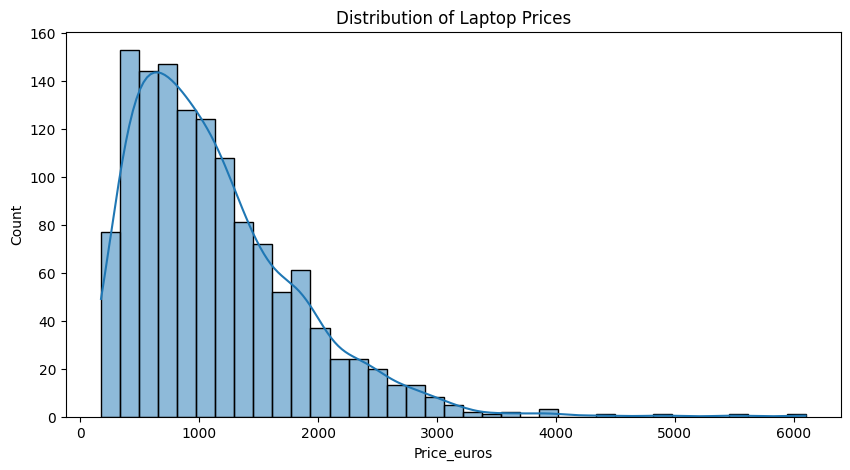

In [5]:
# Plotting the Price distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Price_euros'], kde=True)
plt.title("Distribution of Laptop Prices")
plt.show()

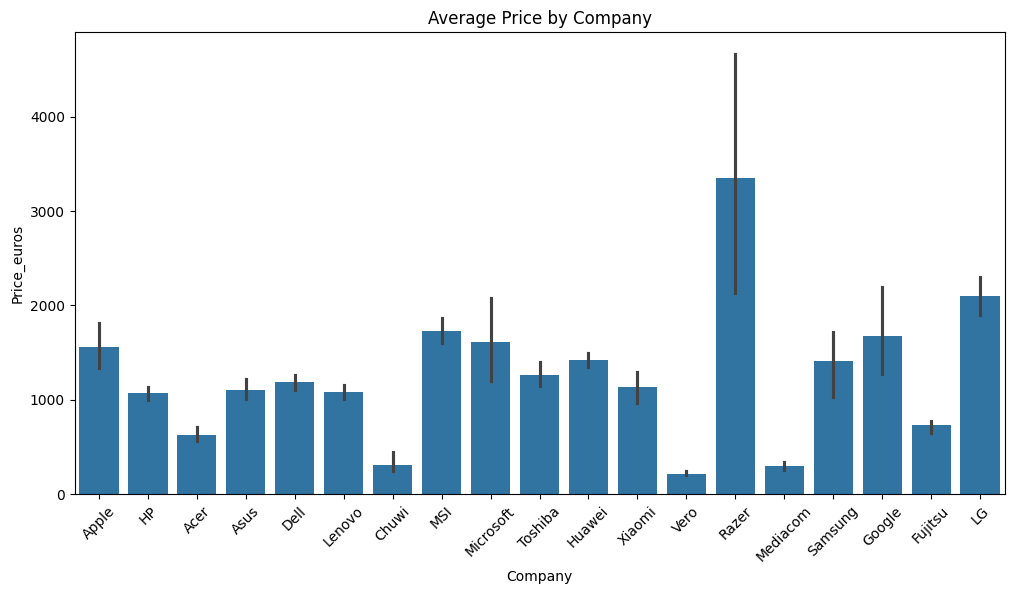

In [6]:
# Now Plotting Brand vs Price
plt.figure(figsize=(12,6))
sns.barplot(x=df['Company'], y=df['Price_euros'])
plt.xticks(rotation=45)
plt.title("Average Price by Company")
plt.show()

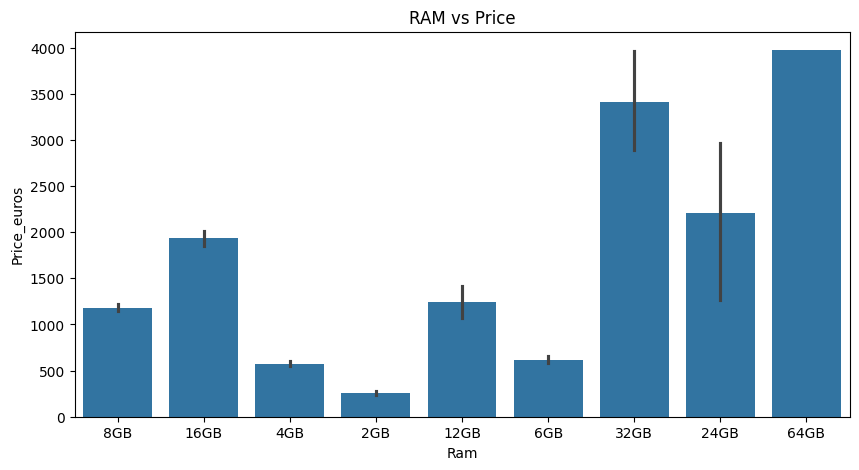

In [7]:
# Plotting RAM vs Price
plt.figure(figsize=(10,5))
sns.barplot(x=df['Ram'], y=df['Price_euros'])
plt.title("RAM vs Price")
plt.show()

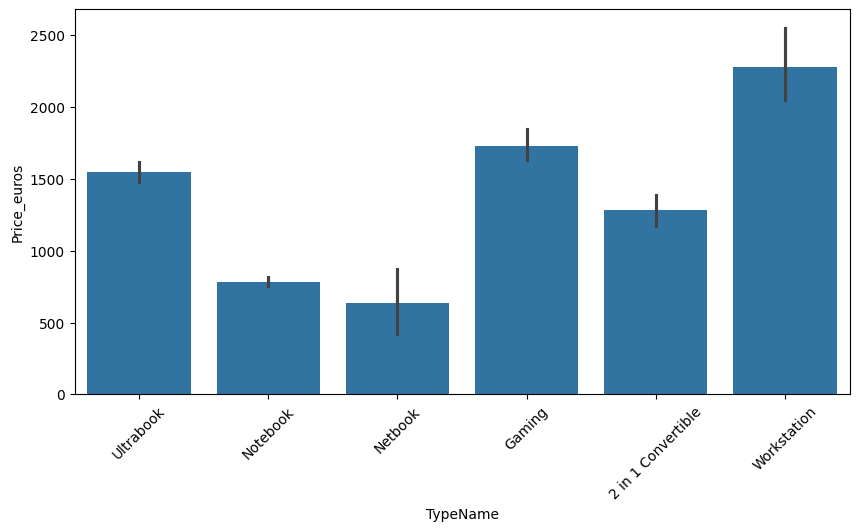

In [8]:
# Typname vs Price
plt.figure(figsize=(10,5))
sns.barplot(x=df['TypeName'], y=df['Price_euros'])
plt.xticks(rotation=45)
plt.show()

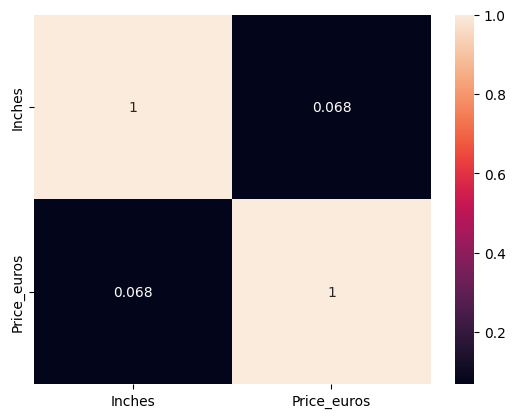

In [9]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.show()

In [10]:
# Some cleaning of the dataset
if df["Ram"].dtype == "object":
    df["Ram"] = df["Ram"].str.replace("GB", "", regex=False)
df["Ram"] = pd.to_numeric(df["Ram"], errors="coerce").astype("Int64")
if df["Weight"].dtype == "object":
    df["Weight"] = df["Weight"].str.replace("kg", "", regex=False)
df["Weight"] = pd.to_numeric(df["Weight"], errors="coerce")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   str    
 1   Product           1303 non-null   str    
 2   TypeName          1303 non-null   str    
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   str    
 5   Cpu               1303 non-null   str    
 6   Ram               0 non-null      Int64  
 7   Memory            1303 non-null   str    
 8   Gpu               1303 non-null   str    
 9   OpSys             1303 non-null   str    
 10  Weight            0 non-null      float64
 11  Price_euros       1303 non-null   float64
dtypes: Int64(1), float64(3), str(8)
memory usage: 123.6 KB


HERE BEGINS THE FEATURE ENGINEERING

In [11]:
# Extracting the Touchscreen feature
df['Touchscreen'] = df['ScreenResolution'].apply(
    lambda x: 1 if 'Touchscreen' in x else 0
)

# IPS Panel 
df['IPS'] = df['ScreenResolution'].apply(
    lambda x: 1 if 'IPS' in x else 0
)

# Resolution
new = df['ScreenResolution'].str.split('x', n=1, expand=True)

df['X_res'] = new[0]
df['Y_res'] = new[1]

df['X_res'] = df['X_res'].str.extract(r'(\d+)$')
df['X_res'] = df['X_res'].astype(int)
df['Y_res'] = df['Y_res'].astype(int)

In [12]:
# Creating PPI (Pixels Per Inch) feature

df['PPI'] = (
    ((df['X_res']**2 + df['Y_res']**2)**0.5) / df['Inches']
)

In [13]:
# Deleting old resolution columns
df.drop(columns=['ScreenResolution','Inches','X_res','Y_res'], inplace=True)

# Extracting CPU brand
df['Cpu Name'] = df['Cpu'].apply(lambda x: " ".join(x.split()[0:3]))

In [14]:
# CPU Brand Classification
def fetch_processor(text):
    if text in ['Intel Core i3', 'Intel Core i5', 'Intel Core i7']:
        return text
    elif text.split()[0] == 'Intel':
        return 'Other Intel Processor'
    else:
        return 'AMD Processor'

df['Cpu Brand'] = df['Cpu Name'].apply(fetch_processor)

df.drop(columns=['Cpu','Cpu Name'], inplace=True)


# Extracting GPU brand
df['Gpu Brand'] = df['Gpu'].apply(lambda x: x.split()[0])

df.drop(columns=['Gpu'], inplace=True)

In [15]:
# Extracting SSD/HDD

df['Memory'] = df['Memory'].astype(str).replace('\.0', '', regex=True)
df["Memory"] = df["Memory"].str.replace('GB', '')
df["Memory"] = df["Memory"].str.replace('TB', '000')


new = df["Memory"].str.split("+", n=1, expand=True)

df["first"] = new[0]
df["first"] = df["first"].str.strip()

df["second"] = new[1]

In [16]:
# Storage
df["SSD"] = df["first"].apply(lambda x: int(x.split()[0]) if "SSD" in x else 0)
df["HDD"] = df["first"].apply(lambda x: int(x.split()[0]) if "HDD" in x else 0)

# second storage
df["SSD"] += df["second"].fillna("0").apply(
    lambda x: int(x.split()[0]) if "SSD" in x else 0
)

df["HDD"] += df["second"].fillna("0").apply(
    lambda x: int(x.split()[0]) if "HDD" in x else 0
)

#dropping temp columns
df.drop(columns=['Memory','first','second'], inplace=True)

In [17]:
df.head()

,Company,Product,TypeName,Ram,OpSys,Weight,Price_euros,Touchscreen,IPS,PPI,Cpu Brand,Gpu Brand,SSD,HDD
0,Apple,MacBook Pro,Ultrabook,<NA>,macOS,NaN,1339.69,0,1,226.983005,Intel Core i5,Intel,128,0
1,Apple,Macbook Air,Ultrabook,<NA>,macOS,NaN,898.94,0,0,127.677940,Intel Core i5,Intel,0,0
2,HP,250 G6,Notebook,<NA>,No OS,NaN,575.00,0,0,141.211998,Intel Core i5,Intel,256,0
3,Apple,MacBook Pro,Ultrabook,<NA>,macOS,NaN,2537.45,0,1,220.534624,Intel Core i7,AMD,512,0
4,Apple,MacBook Pro,Ultrabook,<NA>,macOS,NaN,1803.60,0,1,226.983005,Intel Core i5,Intel,256,0


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1303 non-null   str    
 1   Product      1303 non-null   str    
 2   TypeName     1303 non-null   str    
 3   Ram          0 non-null      Int64  
 4   OpSys        1303 non-null   str    
 5   Weight       0 non-null      float64
 6   Price_euros  1303 non-null   float64
 7   Touchscreen  1303 non-null   int64  
 8   IPS          1303 non-null   int64  
 9   PPI          1303 non-null   float64
 10  Cpu Brand    1303 non-null   str    
 11  Gpu Brand    1303 non-null   str    
 12  SSD          1303 non-null   int64  
 13  HDD          1303 non-null   int64  
dtypes: Int64(1), float64(3), int64(4), str(6)
memory usage: 143.9 KB


TRAINING BEGINS


In [19]:
X = df.drop(columns=['Price_euros'])
y = df['Price_euros']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Encoding
categorical_cols = [
    'Company',
    'Product',
    'TypeName',
    'OpSys',
    'Cpu Brand',
    'Gpu Brand'
 ]

numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', numeric_transformer, numeric_cols)
    ],
    remainder='drop'
 )

In [42]:
# Linear Regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()
pipe_lr = Pipeline([
  ('preprocessor', preprocessor),
  ('model', model)
])

pipe_lr.fit(X_train, y_train)


# prediction
y_pred_lr = pipe_lr.predict(X_test)

e:\DeV\MLxCllg\LapPriceAI\venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['Ram' 'Weight']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
e:\DeV\MLxCllg\LapPriceAI\venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['Ram' 'Weight']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [43]:
# Evaluting Linear Regression
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred_lr))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_lr))

R2 Score: 0.7627220575002139
Mean Absolute Error: 206.84157017200192


In [44]:
# Now Training with Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf)
])

pipe_rf.fit(X_train, y_train)

# prediction
y_pred_rf = pipe_rf.predict(X_test)

e:\DeV\MLxCllg\LapPriceAI\venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['Ram' 'Weight']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
e:\DeV\MLxCllg\LapPriceAI\venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['Ram' 'Weight']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [45]:
# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

MAE: 222.35920968053554
R2 Score: 0.7225607876304151


In [46]:
# Now train with Train Desicion Tree 
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

pipe_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('model', dt)
])

pipe_dt.fit(X_train, y_train)

y_pred_dt = pipe_dt.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("R2 Score:", r2_score(y_test, y_pred_dt))

MAE: 254.35701149425284
R2 Score: 0.6507710625489784


e:\DeV\MLxCllg\LapPriceAI\venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['Ram' 'Weight']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
e:\DeV\MLxCllg\LapPriceAI\venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['Ram' 'Weight']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [47]:
# Creating Comaprison Table

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Decision Tree"],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_dt)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_dt)
    ]
})

print(results)

               Model  R2 Score         MAE
0  Linear Regression  0.762722  206.841570
1      Random Forest  0.722561  222.359210
2      Decision Tree  0.650771  254.357011


In [48]:
# Although Random Forest had slightly lower MAE, Linear Regression achieved the highest R² score and offered better interpretability. Since both performed similarly, Linear Regression was selected for its simplicity and strong predictive capability.

In [49]:
# Hyperparameter Tuning for Random Forest
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor



In [50]:
# Grid Parameters

params = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5]
}

In [51]:
# Grid Search

grid = GridSearchCV(
    pipe_rf,
    param_grid=params,
    cv=3,
    scoring='r2',
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


e:\DeV\MLxCllg\LapPriceAI\venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['Ram' 'Weight']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10, 20, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is disp

In [52]:

print(grid.best_params_)
print(grid.best_score_)

{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
0.745146708067907


In [53]:
#Predict Tuned Model
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("Tuned R2:", r2_score(y_test, y_pred_best))
print("Tuned MAE:", mean_absolute_error(y_test, y_pred_best))

Tuned R2: 0.7225607876304151
Tuned MAE: 222.35920968053554


e:\DeV\MLxCllg\LapPriceAI\venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['Ram' 'Weight']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [54]:
# Saving the model
import joblib

joblib.dump(pipe_lr, "../backend/model.pkl")

['../backend/model.pkl']